# 企業間エントロピー比較

指定した複数企業について、同一年の **年間出願件数** と **区分別エントロピー** を比較する。

| 軸 | 意味 |
|---|---|
| x（年間出願件数） | その年に出願した延べ区分数の合計 |
| y（正規化エントロピー） | 0 = 特定区分に集中、1 = 全45区分に均等分散 |

In [26]:
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd

from utils.db import get_conn
from utils.trademark_utils import parse_filing_date, extract_classes, calc_entropy, year_like_patterns

matplotlib.rcParams['font.family'] = 'Meiryo'
print('セットアップ完了')

セットアップ完了


---

## 1. 検索条件の入力

`target_years`（単年/複数年/範囲）と `target_company_ids` を設定してから次のセルを実行すること。

In [27]:
# ===== 検索条件を入力 =====
target_years        = [2018, 2019, 2020]   # 例: 2020（単年） / [2018, 2019, 2020]（複数年） / range(2018, 2021)（範囲）
target_company_ids = [131094, 135748, 134855, 3584, 307010096, 506113602, 105637, 595030295, 500040182, 106195, 505187024, 505269995, 709006024]   # 例: [131094, 3207, 186588]
# target_company_ids = [131094, 135748, 134855, 3584, 307010096, 506113602, 105637, 595030295, 500040182, 106195, 505187024, 505269995, 709006024]   # 例: [131094, 3207, 186588]
# ==========================

# --- 入力値の正規化 ---
if isinstance(target_years, int):
    target_years = [target_years]
elif isinstance(target_years, range):
    target_years = list(target_years)
else:
    target_years = sorted(set(target_years))

# --- 入力値の検証 ---
_errors = []
if not target_years:
    _errors.append('  • target_years が未設定です（西暦4桁の整数、またはそのリスト/rangeで入力してください）')
if not target_company_ids:
    _errors.append('  • target_company_ids が未設定です（整数のリスト）')
if _errors:
    raise ValueError(
        '以下の入力が不足しています。値を設定してからセルを再実行してください。\n'
        + '\n'.join(_errors)
    )

# 表示用ラベル（連続年は範囲表記、それ以外は列挙）
def _years_label(years):
    years = sorted(years)
    if len(years) == 1:
        return f'{years[0]}年'
    if years == list(range(years[0], years[-1] + 1)):
        return f'{years[0]}〜{years[-1]}年'
    return '・'.join(f'{y}年' for y in years)

years_label = _years_label(target_years)

print(f'対象年      : {years_label}')
print(f'対象企業 ID : {target_company_ids}  （{len(target_company_ids)} 社）')

対象年      : 2018〜2020年
対象企業 ID : [131094, 135748, 134855, 3584, 307010096, 506113602, 105637, 595030295, 500040182, 106195, 505187024, 505269995, 709006024]  （13 社）


---

## 2. データ取得

In [28]:
_year_patterns = year_like_patterns(target_years)

with get_conn() as conn:
    df_year = pd.read_sql("""
        SELECT
            "right-holder-group-identification-number"  AS company_id,
            "right-holder-group-name"                   AS company_name,
            "filing-date"                               AS filing_date_raw,
            "goods-and-service-name-and-code"           AS goods_and_service,
            "number-of-goods-service-class"             AS num_classes
        FROM trademark_db
        WHERE "goods-and-service-name-and-code"             IS NOT NULL
          AND "filing-date"                                  IS NOT NULL
          AND "right-holder-group-identification-number"    = ANY(%(ids)s)
          AND "filing-date"                                  LIKE ANY(%(patterns)s)
    """, conn, params={'ids': target_company_ids, 'patterns': _year_patterns})

if df_year.empty:
    raise ValueError(
        f'指定した company_ids {target_company_ids} / {years_label} に該当するデータが見つかりませんでした。'
    )

# LIKE は年の絞り込みの粗いフィルタなので、filing_date をパースして念のため厳密に再確認
df_year['filing_date'] = df_year['filing_date_raw'].apply(parse_filing_date)
df_year['filing_year'] = df_year['filing_date'].apply(lambda d: d.year if d else None)
df_year = df_year[df_year['filing_year'].isin(target_years)].copy()

# 取得できなかった企業を報告
found_ids    = set(df_year['company_id'].unique())
missing_ids  = set(target_company_ids) - found_ids
if missing_ids:
    print(f'[警告] {years_label}のデータが見つからなかった company_id: {sorted(missing_ids)}')

if df_year.empty:
    raise ValueError(
        f'{years_label}のデータがいずれの企業にも見つかりませんでした。'
    )

print(f'取得件数: {len(df_year):,} 件  対象企業数: {len(found_ids)} 社')
df_year.head(3)

C:\Users\k-fukuzawa\AppData\Local\Temp\ipykernel_6720\3490627923.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_year = pd.read_sql("""


[警告] 2018〜2020年のデータが見つからなかった company_id: [105637]
取得件数: 3,239 件  対象企業数: 12 社


,company_id,company_name,filing_date_raw,goods_and_service,num_classes,filing_date,filing_year
0,505269995,エイベックス株式会社,平成３０年１月１６日（２０１８．１．１６）,第９類 腕時計型携帯情報端末，スマートフォン，パソコン用アプリケーションソフトウェア，携帯...,3,2018-01-16,2018
1,135748,株式会社バンダイ,平成３０年１月１６日（２０１８．１．１６）,第４１類 教育に関する情報の提供，コンピュータネットワークを介した教育情報の提供，技芸・ス...,2,2018-01-16,2018
2,135748,株式会社バンダイ,平成３０年１月３０日（２０１８．１．３０）,第３０類 コーヒー，ココア，キャンディー，ポップコーン，アイスクリーム，玩具菓子，玩具付き...,1,2018-01-30,2018


---

## 3. 前処理（区分番号の展開）

In [29]:
df_year['class_list'] = df_year['goods_and_service'].apply(extract_classes)

df_exploded = (
    df_year
    .explode('class_list')
    .dropna(subset=['class_list'])
    .rename(columns={'class_list': 'class_number'})
    .astype({'class_number': int})
)

print(f'展開後件数: {len(df_exploded):,} 件')

展開後件数: 9,216 件


---

## 4. エントロピー計算

In [30]:
# 企業ごとの年間平均区分数（出願単位の num_classes を平均、複数年指定時は対象期間全体で平均）
avg_classes_map = df_year.groupby('company_id')['num_classes'].mean().to_dict()

rows = []
for (cid, cname), grp in df_exploded.groupby(['company_id', 'company_name']):
    counts = grp.groupby('class_number')['class_number'].count()
    metrics = calc_entropy(counts)
    rows.append({
        'company_id':          cid,
        'company_name':        cname,
        'avg_classes':         avg_classes_map.get(cid),
        **metrics,
    })

df_result = (
    pd.DataFrame(rows)
    .sort_values('entropy_normalized', ascending=False)
    .reset_index(drop=True)
)[['company_id', 'company_name', 'total_applications', 'avg_classes', 'entropy', 'entropy_normalized', 'n_classes_used']]

df_result.columns = [
    '企業ID', '企業名',
    '年間出願件数（延べ区分）',
    '1出願あたり平均区分指定数',
    'エントロピー (bits)', '正規化エントロピー',
    '使用区分数',
]
df_result['1出願あたり平均区分指定数'] = df_result['1出願あたり平均区分指定数'].round(2)

print(f'{years_label}  企業間エントロピー比較')
df_result

2018〜2020年  企業間エントロピー比較


,企業ID,企業名,年間出願件数（延べ区分）,1出願あたり平均区分指定数,エントロピー (bits),正規化エントロピー,使用区分数
0,131094,株式会社サンリオ,4869,2.76,5.3486,0.9739,44
1,505187024,株式会社スタジオジブリ,38,19.00,4.6163,0.8406,26
2,500040182,東映アニメーション株式会社,161,5.96,4.3710,0.7959,24
3,709006024,株式会社ベネッセコーポレーション,373,5.11,4.2855,0.7803,45
4,505269995,エイベックス株式会社,426,4.84,4.1833,0.7617,26
5,135748,株式会社バンダイ,897,2.64,3.7847,0.6891,31
6,307010096,フリュー株式会社,559,3.65,3.6095,0.6572,25
7,134855,株式会社バンダイナムコエンターテインメント,771,3.46,3.5292,0.6426,21
8,595030295,株式会社タカラトミーアーツ,204,4.16,3.4750,0.6328,17
9,106195,サンエックス株式会社,89,3.87,3.2820,0.5976,13


---

## 5. 散布図：年間出願件数 × 正規化エントロピー

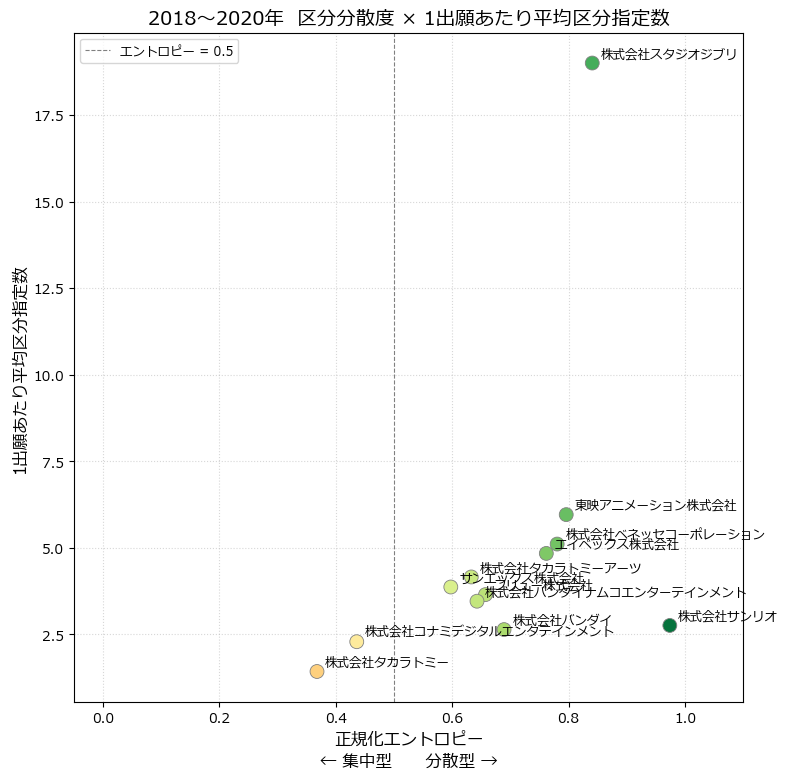

In [39]:
x = df_result['正規化エントロピー']
y = df_result['1出願あたり平均区分指定数']
names = df_result['企業名']

fig, ax = plt.subplots(figsize=(8, 8))

scatter = ax.scatter(
    x, y,
    c=x, cmap='RdYlGn', vmin=0, vmax=1,
    s=100, edgecolors='grey', linewidths=0.6, zorder=3
)

# 企業名ラベルを各点の右上に表示
for xi, yi, name in zip(x, y, names):
    ax.annotate(
        name,
        xy=(xi, yi), xytext=(6, 4),
        textcoords='offset points',
        fontsize=9,
    )

# 参考線（エントロピー 0.5 の垂直線）
ax.axvline(x=0.5, color='grey', linestyle='--', linewidth=0.8, label='エントロピー = 0.5')

# # 横軸（正規化エントロピー）と対応させ、カラーバーもグラフ下に横向きで配置（幅は shrink で縮小）
# cbar = fig.colorbar(scatter, ax=ax, orientation='horizontal', pad=0.12, shrink=0.65)
# cbar.set_label('正規化エントロピー')

ax.set_xlabel('正規化エントロピー\n← 集中型　　分散型 →', fontsize=12)
ax.set_ylabel('1出願あたり平均区分指定数', fontsize=12)
ax.set_title(f'{years_label}  区分分散度 × 1出願あたり平均区分指定数', fontsize=14)
ax.set_xlim(-0.05, 1.1)
ax.set_box_aspect(1)  # プロット領域を縦横比 1:1 に固定
ax.legend(fontsize=9)
ax.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

---

## 6. 散布図：正規化エントロピー × 使用区分数

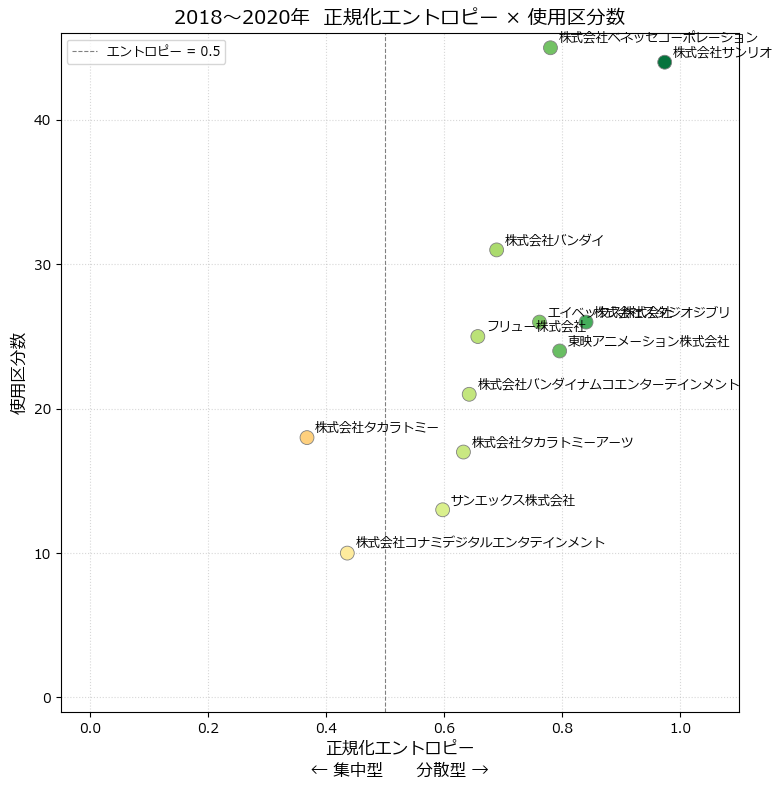

In [40]:
x2 = df_result['正規化エントロピー']
y2 = df_result['使用区分数']
names2 = df_result['企業名']

fig, ax = plt.subplots(figsize=(8, 8))

scatter2 = ax.scatter(
    x2, y2,
    c=x2, cmap='RdYlGn', vmin=0, vmax=1,
    s=100, edgecolors='grey', linewidths=0.6, zorder=3
)

# 企業名ラベルを各点の右上に表示
for xi, yi, name in zip(x2, y2, names2):
    ax.annotate(
        name,
        xy=(xi, yi), xytext=(6, 4),
        textcoords='offset points',
        fontsize=9,
    )

# 参考線（エントロピー 0.5 の垂直線）
ax.axvline(x=0.5, color='grey', linestyle='--', linewidth=0.8, label='エントロピー = 0.5')

# cbar2 = fig.colorbar(scatter2, ax=ax, orientation='horizontal', pad=0.12, shrink=0.5)
# cbar2.set_label('正規化エントロピー')

ax.set_xlabel('正規化エントロピー\n← 集中型　　分散型 →', fontsize=12)
ax.set_ylabel('使用区分数', fontsize=12)
ax.set_title(f'{years_label}  正規化エントロピー × 使用区分数', fontsize=14)
ax.set_xlim(-0.05, 1.1)
ax.set_ylim(-1, 46)
ax.set_box_aspect(1)  # プロット領域を縦横比 1:1 に固定
ax.legend(fontsize=9)
ax.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()